In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc
from sklearn.feature_extraction.text import CountVectorizer

In [2]:
# Load Data
df = pd.read_csv("../datasets/spam.csv", encoding='latin-1')
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [3]:
# Data Info
print(df.info())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB
None
v1               0
v2               0
Unnamed: 2    5522
Unnamed: 3    5560
Unnamed: 4    5566
dtype: int64


In [4]:
# Data Cleaning
df = df[['v1', 'v2']]
df.columns = ['label', 'message']

df['label'] = df['label'].map({'ham': 0, 'spam': 1})

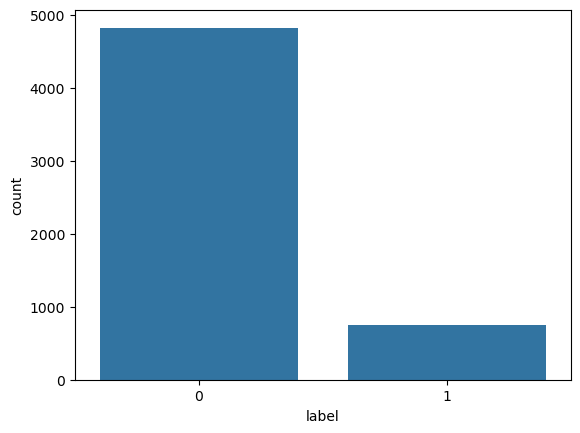

In [5]:
# Visualization
sns.countplot(x='label', data=df)
plt.show()

In [6]:
# Feature Extraction
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(df['message'])

y = df['label']

In [7]:
# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [8]:
# Model Training
model = MultinomialNB()
model.fit(X_train, y_train)

MultinomialNB()

In [9]:
# Prediction
y_pred = model.predict(X_test)

In [10]:
# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9856502242152466
[[953  12]
 [  4 146]]
              precision    recall  f1-score   support

           0       1.00      0.99      0.99       965
           1       0.92      0.97      0.95       150

    accuracy                           0.99      1115
   macro avg       0.96      0.98      0.97      1115
weighted avg       0.99      0.99      0.99      1115



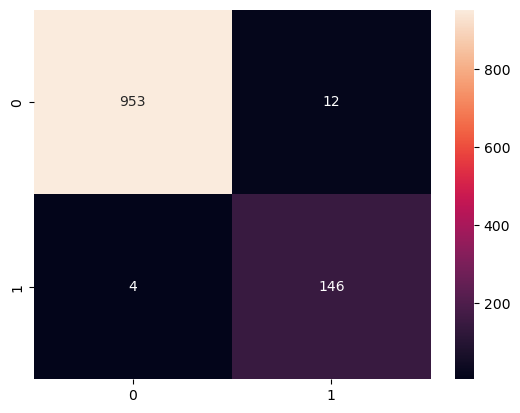

In [11]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.show()

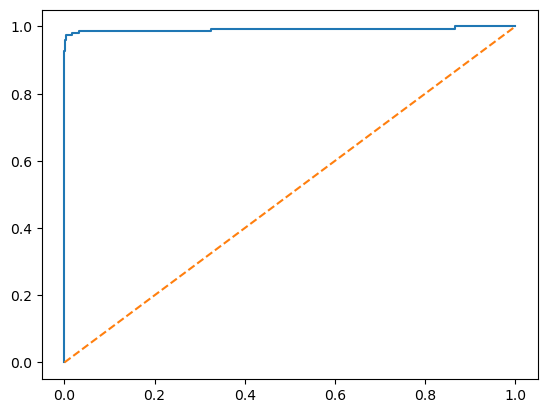

In [12]:
# ROC Curve
y_prob = model.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], linestyle='--')
plt.show()

In [13]:
# Prediction (Input → Output)

# Input
sample_text = ["Congratulations! You won a free lottery ticket"]
print("Input:", sample_text)

sample_vector = vectorizer.transform(sample_text)

# Output
prediction = model.predict(sample_vector)
print("Output:", "Spam" if prediction[0] == 1 else "Ham")

Input: ['Congratulations! You won a free lottery ticket']
Output: Spam
